# Selection Algorithm Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data=pd.read_csv('ga_selection_analysis.csv',index_col='Generation')

In [5]:
data.head()

,tournament|positionbased|global_perm|elitism=True,tournament|positionbased|random_swap|elitism=True,tournament|positionbased_2child|random_swap|elitism=True,tournament|blockwise|random_swap|elitism=True,tournament|blockwise_2child|global_perm|elitism=True,tournament|positionbased|between_teams|elitism=True,fitness_proportionate|positionbased|global_perm|elitism=True,fitness_proportionate|positionbased|random_swap|elitism=True,fitness_proportionate|positionbased_2child|random_swap|elitism=True,fitness_proportionate|blockwise|random_swap|elitism=True,fitness_proportionate|blockwise_2child|global_perm|elitism=True,fitness_proportionate|positionbased|between_teams|elitism=True
Generation,,,,,,,,,,,,
0,0.758856,0.744681,0.751463,0.744681,0.755049,0.766249,0.723483,0.751463,0.751463,0.758856,0.751463,0.748072
1,0.783079,0.766249,0.774370,0.783079,0.813953,0.802709,0.762442,0.778724,0.778724,0.778724,0.770309,0.783079
2,0.792894,0.802709,0.797595,0.826476,0.833575,0.813953,0.783079,0.802709,0.787780,0.787780,0.797595,0.787780
3,0.808331,0.813953,0.802709,0.857193,0.857193,0.826476,0.808331,0.802709,0.792480,0.813953,0.808331,0.797595
4,0.826476,0.826476,0.813953,0.877215,0.877215,0.826476,0.813953,0.808331,0.802709,0.813953,0.813953,0.802709


In [6]:
data.tail()

,tournament|positionbased|global_perm|elitism=True,tournament|positionbased|random_swap|elitism=True,tournament|positionbased_2child|random_swap|elitism=True,tournament|blockwise|random_swap|elitism=True,tournament|blockwise_2child|global_perm|elitism=True,tournament|positionbased|between_teams|elitism=True,fitness_proportionate|positionbased|global_perm|elitism=True,fitness_proportionate|positionbased|random_swap|elitism=True,fitness_proportionate|positionbased_2child|random_swap|elitism=True,fitness_proportionate|blockwise|random_swap|elitism=True,fitness_proportionate|blockwise_2child|global_perm|elitism=True,fitness_proportionate|positionbased|between_teams|elitism=True
Generation,,,,,,,,,,,,
95,0.90342,0.945946,0.945946,0.945946,0.945946,0.945946,0.90342,0.945946,0.945946,0.945946,0.945946,0.90342
96,0.90342,0.945946,0.945946,0.945946,0.945946,0.945946,0.90342,0.945946,0.945946,0.945946,0.945946,0.90342
97,0.90342,0.945946,0.945946,0.945946,0.945946,0.945946,0.90342,0.945946,0.945946,0.945946,0.945946,0.90342
98,0.90342,0.945946,0.945946,0.945946,0.945946,0.945946,0.90342,0.945946,0.945946,0.945946,0.945946,0.90342
99,0.90342,0.945946,0.945946,0.945946,0.945946,0.945946,0.90342,0.945946,0.945946,0.945946,0.945946,0.90342


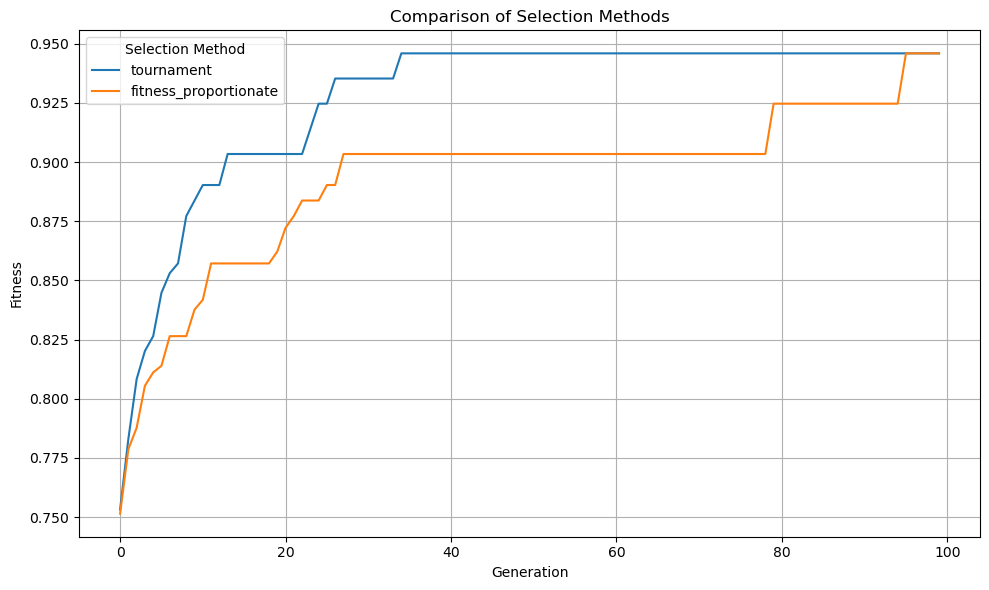

In [7]:
selection_results = {}

# iterate through each column in the dataset
for col in data.columns:
    selection_method = col.split("|")[0]  # extract "tournament" or "fitness_proportionate"
    #initialize list for each method
    if selection_method not in selection_results:
        selection_results[selection_method] = []
    
    # add column to the appropriate selection method group
    selection_results[selection_method].append(data[col])

# compute the median fitness per generation across all configurations of the same selection method
selection_avg_df = pd.DataFrame({
    method: pd.concat(columns, axis=1).median(axis=1)
    for method, columns in selection_results.items()
})

# plot
plt.figure(figsize=(10, 6))

for method in selection_avg_df.columns:
    plt.plot(selection_avg_df.index, selection_avg_df[method], label=method)

plt.title("Comparison of Selection Methods")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend(title="Selection Method")
plt.grid(True)
plt.tight_layout()
plt.show()

Moving forward we will use the tournament method to evaluate the best combination of crossover and mutation